# TikTok Cluster Insight Notebook
Notebook này được viết theo hướng **sạch, rõ ràng, dễ thay đổi** để bạn phân tích **10 hướng insight cụm** trên dataset creator TikTok.

## Cách dùng nhanh
1. Đổi `CLUSTER_COL` ở phần cấu hình thành một trong các cột:
   - `cluster_kmeans`
   - `cluster_hierarchical`
   - `cluster_dbscan`
   - `cluster_spectral`
2. Chạy lần lượt từ trên xuống.
3. Mỗi hướng phân tích là một section riêng, có thể chạy độc lập sau khi đã chạy phần `Setup + Helper functions`.

## 10 hướng phân tích trong notebook
1. Bản đồ tổng quan các cụm  
2. Định vị giá và lệch giá  
3. Benchmark / relative competitiveness  
4. Hook vs retention  
5. Organic → collaboration → commercial  
6. Recent momentum và stability  
7. Audience fit  
8. Content vertical archetypes  
9. Mâu thuẫn nội tại của cụm  
10. Opportunity map cho brand / platform / creator

In [17]:

from __future__ import annotations

import warnings
from pathlib import Path
from typing import Iterable, List, Optional

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"

In [18]:

# =========================
# Configuration
# =========================

CANDIDATE_PATHS = [
    Path("data_insights.csv"),
    Path("/mnt/data/data_insights.csv"),
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), CANDIDATE_PATHS[0])
CLUSTER_COL = "cluster_hierarchical"   # đổi ở đây khi muốn phân tích model khác
SAVE_TABLES = False
OUTPUT_DIR = Path("cluster_insight_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
EPS = 1e-9

print("DATA_PATH:", DATA_PATH)
print("CLUSTER_COL:", CLUSTER_COL)

DATA_PATH: data_insights.csv
CLUSTER_COL: cluster_hierarchical


In [19]:

# =========================
# Feature groups
# =========================

channel_size_cols = [
    "followerCnt",
    "startingRate100k",
    "recommendRate100k",
]

rank_cols = [
    "followersGrowthRateRank",
    "avgSixSecondsViewsRateRank",
    "medianViewsRank",
    "videoCompleteRateRank",
    "engagementRateRank",
]

benchmark_cols = [
    "avgSixSecondsViewsBenchMarkViews",
    "medianBenchMarkViews",
    "engagementRateBenchMark",
]

performance_cols = [
    "followersGrowthRate",
    "avgSixSecondsViewsRate",
    "videoCompleteRate",
    "engagementRate",
    "medianViews",
    "broadcastingScore",
    "collaborationScore",
    "commercialScore",
]

audience_cols = [
    "active_active", "active_inactive",
    "age_18-24", "age_25-34", "age_13-17",
    "age_35-44", "age_55+", "age_45-54", "age_Other",
    "device_APPLE", "device_SAMSUNG", "device_OPPO",
    "device_XIAOMI", "device_VIVO", "device_Other",
    "gender_Female", "gender_Male",
    "country_VN", "country_US", "country_JP", "country_TW",
    "country_KR", "country_MM", "country_KH",
    "country_TH", "country_PH", "country_ID",
]

content_cols = [
    "Beauty", "Education", "Entertainment", "Food", "Sports"
]

performance_recent_cols = [
    "total_views_recent",
    "total_hearts_recent",
    "total_comments_recent",
    "median_view_recent",
    "max_view_recent",
    "cov_view_recent",
    "burstiness_recent",
    "recency_days_recent",
]

available_cluster_cols = [
    "cluster_kmeans",
    "cluster_hierarchical",
    "cluster_dbscan",
    "cluster_spectral",
]

all_feature_cols = (
    channel_size_cols
    + rank_cols
    + benchmark_cols
    + performance_cols
    + audience_cols
    + content_cols
    + performance_recent_cols
)

In [20]:

# =========================
# Load data
# =========================

df = pd.read_csv(DATA_PATH)

missing_expected = [c for c in (all_feature_cols + available_cluster_cols + ["handleName"]) if c not in df.columns]
if missing_expected:
    raise ValueError(f"Dataset đang thiếu các cột sau: {missing_expected}")

print("Shape:", df.shape)
print("\nDtypes:")
display(df.dtypes.value_counts().rename_axis("dtype").to_frame("n_cols"))

print("\nAvailable cluster columns:", available_cluster_cols)
for c in available_cluster_cols:
    print(f"{c}:")
    display(df[c].value_counts(dropna=False).sort_index().rename("count").to_frame())

display(df.head(3))

Shape: (5089, 66)

Dtypes:


,n_cols
dtype,
float64,51
int64,14
object,1



Available cluster columns: ['cluster_kmeans', 'cluster_hierarchical', 'cluster_dbscan', 'cluster_spectral']
cluster_kmeans:


,count
cluster_kmeans,
0,788
1,3966
2,322
3,13


cluster_hierarchical:


...

cluster_dbscan:


,count
cluster_dbscan,
-1,148
0,4922
1,19


cluster_spectral:


,count
cluster_spectral,
0,548
1,775
2,791
3,90
4,2885


,handleName,followerCnt,startingRate100k,recommendRate100k,followersGrowthRateRank,avgSixSecondsViewsRateRank,medianViewsRank,videoCompleteRateRank,engagementRateRank,avgSixSecondsViewsBenchMarkViews,medianBenchMarkViews,engagementRateBenchMark,followersGrowthRate,avgSixSecondsViewsRate,videoCompleteRate,engagementRate,medianViews,broadcastingScore,collaborationScore,commercialScore,active_active,active_inactive,age_18-24,age_25-34,age_13-17,age_35-44,age_55+,age_45-54,age_Other,device_APPLE,device_SAMSUNG,device_OPPO,device_XIAOMI,device_VIVO,device_Other,gender_Female,gender_Male,country_VN,country_US,country_JP,country_TW,country_KR,country_MM,country_KH,country_TH,country_PH,country_ID,Beauty,Education,Entertainment,Food,Sports,total_views_recent,total_hearts_recent,total_comments_recent,median_view_recent,max_view_recent,cov_view_recent,burstiness_recent,recency_days_recent,cluster_kmeans,cluster_hierarchical,cluster_dbscan,cluster_spectral,cluster_dbscan_7,cluster_kmeans_8
0,nguyen_huynh_tien,3124254,2000000000000,666265440077,0.002100,0.7786,0.6287,0.325691,0.0100,0.4604,102913.0,0.0391,-0.009193,0.3096,0.113298,0.1549,48073.0,94.5,84.0,60.0,0.639185,0.360815,0.385387,0.313601,0.136034,0.086794,0.043907,0.000000,0.000000,0.240124,0.175536,0.178162,0.146819,0.074108,0.185251,0.353043,0.646957,0.357588,0.00000,0.00000,0.000000,0.000000,0.062347,0.000000,0.093147,0.078531,0.060136,0,0,1,0,0,750408.0,6037.0,675.0,38135.0,214241.0,0.956610,0.160784,1.449954,1,2,0,1,0,7
1,khuyenduong299,1671668,0,997330412878,0.747853,0.8526,0.8090,0.588344,0.2832,0.4607,102500.0,0.0391,0.006861,0.2484,0.178087,0.0472,11508.0,95.8,75.6,90.4,0.832188,0.167812,0.379810,0.453353,0.028418,0.088447,0.000000,0.023416,0.000000,0.559109,0.162600,0.127199,0.084275,0.032329,0.034488,0.465005,0.534995,0.960034,0.00962,0.00532,0.003371,0.003643,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,1,0,0,19817700.0,874473.0,13842.0,552760.0,5706630.0,1.119467,-0.008681,3.432419,0,1,0,2,0,2
2,n.huyen2k4,2062494,0,711443766513,0.049416,0.7579,0.4392,0.341017,0.0127,0.4604,102913.0,0.0391,-0.003541,0.3278,0.117057,0.1279,128875.0,93.1,88.4,84.0,0.356330,0.643670,0.437555,0.280522,0.156289,0.058234,0.000000,0.000000,0.039801,0.401401,0.164859,0.201277,0.097832,0.064009,0.070621,0.170222,0.829778,0.902107,0.00000,0.00000,0.000000,0.000000,0.019195,0.008213,0.020363,0.000000,0.011523,1,0,1,0,0,1820043.0,9929.0,789.0,133570.0,205020.0,0.511231,-0.414296,2.594803,0,1,0,2,0,2


In [21]:

# =========================
# Helper functions
# =========================

def safe_divide(num, den, eps: float = EPS):
    num = pd.Series(num, index=getattr(num, "index", None)) if not isinstance(num, pd.Series) else num
    den = pd.Series(den, index=getattr(num, "index", None)) if not isinstance(den, pd.Series) else den
    return num / (den.replace(0, np.nan) + eps)

def validate_cluster_col(df: pd.DataFrame, cluster_col: str) -> None:
    if cluster_col not in df.columns:
        raise ValueError(f"{cluster_col} không tồn tại trong dataframe.")
    if df[cluster_col].nunique(dropna=False) < 2:
        raise ValueError(f"{cluster_col} phải có ít nhất 2 cụm.")

def make_cluster_frame(df: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    validate_cluster_col(df, cluster_col)
    out = df.copy()
    out[cluster_col] = out[cluster_col].astype(str)
    return out

def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Pricing
    out["price_gap"] = out["startingRate100k"] - out["recommendRate100k"]
    out["price_ratio"] = safe_divide(out["startingRate100k"], out["recommendRate100k"])

    # Relative performance vs benchmark
    out["views_vs_benchmark"] = safe_divide(out["medianViews"], out["medianBenchMarkViews"])
    out["engagement_vs_benchmark"] = safe_divide(out["engagementRate"], out["engagementRateBenchMark"])

    # Attention vs retention
    out["hook_hold_gap"] = out["avgSixSecondsViewsRate"] - out["videoCompleteRate"]

    # Brand funnel tensions
    out["organic_commercial_gap"] = out["broadcastingScore"] - out["commercialScore"]
    out["collab_commercial_gap"] = out["collaborationScore"] - out["commercialScore"]

    # Recent momentum / stability
    out["spike_ratio"] = safe_divide(out["max_view_recent"], out["median_view_recent"])
    out["recent_interactions"] = out["total_hearts_recent"] + out["total_comments_recent"]
    out["recent_interaction_per_view"] = safe_divide(out["recent_interactions"], out["total_views_recent"])
    out["recent_stability_proxy"] = 1 / (out["cov_view_recent"] + 1)
    out["recent_momentum_proxy"] = (
        np.log1p(out["median_view_recent"].clip(lower=0))
        + np.log1p(out["total_views_recent"].clip(lower=0))
        + out["followersGrowthRate"].clip(lower=0)
        - np.log1p(out["recency_days_recent"].clip(lower=0))
    )

    # Audience utilization
    out["active_utilization"] = safe_divide(out["engagementRate"], out["active_active"])

    return out

def cluster_size_table(df: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    out = (
        df[cluster_col]
        .value_counts(dropna=False)
        .rename_axis(cluster_col)
        .reset_index(name="n_creators")
    )
    out["pct"] = out["n_creators"] / len(df)
    return out.sort_values("n_creators", ascending=False)

def summarize_by_cluster(
    df: pd.DataFrame,
    cluster_col: str,
    cols: List[str],
    stat: str = "median"
) -> pd.DataFrame:
    use_cols = [c for c in cols if c in df.columns]
    if stat == "median":
        out = df.groupby(cluster_col)[use_cols].median(numeric_only=True)
    elif stat == "mean":
        out = df.groupby(cluster_col)[use_cols].mean(numeric_only=True)
    else:
        raise ValueError("stat chỉ nhận 'median' hoặc 'mean'")
    return out

def robust_standardize_table(table: pd.DataFrame) -> pd.DataFrame:
    median = table.median(axis=0)
    iqr = table.quantile(0.75, axis=0) - table.quantile(0.25, axis=0)
    iqr = iqr.replace(0, np.nan)
    out = (table - median) / iqr
    return out.fillna(0)

def plot_heatmap(
    table: pd.DataFrame,
    title: str,
    center: float = 0,
    cmap: str = "coolwarm",
    fmt: str = ".2f",
    figsize: tuple = (14, 6),
):
    plt.figure(figsize=figsize)
    sns.heatmap(table, annot=True, fmt=fmt, cmap=cmap, center=center, linewidths=0.5)
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def plot_cluster_sizes(df: pd.DataFrame, cluster_col: str):
    size_tbl = cluster_size_table(df, cluster_col)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=size_tbl, x=cluster_col, y="n_creators", color=sns.color_palette("deep")[0])
    ax.set_title(f"Cluster size - {cluster_col}")
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=11
        )
    plt.tight_layout()
    plt.show()
    return size_tbl

def plot_box_grid(
    df: pd.DataFrame,
    cluster_col: str,
    cols: List[str],
    ncols: int = 3,
    log_cols: Optional[Iterable[str]] = None,
    kind: str = "box",
):
    use_cols = [c for c in cols if c in df.columns]
    log_cols = set(log_cols or [])
    n = len(use_cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, use_cols):
        tmp = df[[cluster_col, col]].copy()
        if col in log_cols:
            tmp[col] = np.log1p(tmp[col].clip(lower=0))
            label = f"log1p({col})"
        else:
            label = col

        if kind == "violin":
            sns.violinplot(data=tmp, x=cluster_col, y=col, ax=ax, inner="quartile", color=sns.color_palette("deep")[0])
        else:
            sns.boxplot(data=tmp, x=cluster_col, y=col, ax=ax, showfliers=False, color=sns.color_palette("deep")[0])

        ax.set_title(label)
        ax.set_xlabel(cluster_col)
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=0)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def plot_cluster_scatter(
    df: pd.DataFrame,
    cluster_col: str,
    x: str,
    y: str,
    size: Optional[str] = None,
    log_x: bool = False,
    log_y: bool = False,
    title: Optional[str] = None,
):
    tmp = df[[cluster_col, x, y] + ([size] if size else [])].copy()

    if log_x:
        tmp[x] = np.log1p(tmp[x].clip(lower=0))
    if log_y:
        tmp[y] = np.log1p(tmp[y].clip(lower=0))

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=tmp,
        x=x,
        y=y,
        hue=cluster_col,
        size=size,
        sizes=(30, 250) if size else None,
        alpha=0.7,
        palette="tab10",
    )
    plt.title(title or f"{y} vs {x} by {cluster_col}")
    plt.tight_layout()
    plt.show()

def dominant_label_table(df: pd.DataFrame, cluster_col: str, cols: List[str], prefix: str) -> pd.DataFrame:
    use_cols = [c for c in cols if c in df.columns]
    tmp = df[[cluster_col] + use_cols].copy()
    tmp[f"dominant_{prefix}"] = tmp[use_cols].idxmax(axis=1)
    out = (
        tmp.groupby([cluster_col, f"dominant_{prefix}"])
        .size()
        .rename("n")
        .reset_index()
    )
    out["pct_within_cluster"] = out["n"] / out.groupby(cluster_col)["n"].transform("sum")
    return out.sort_values([cluster_col, "pct_within_cluster"], ascending=[True, False])

def export_table(table: pd.DataFrame, name: str):
    if SAVE_TABLES:
        path = OUTPUT_DIR / f"{name}.csv"
        table.to_csv(path, index=True if table.index.name else False)
        print(f"Saved -> {path}")

def print_section(title: str):
    print("\n" + "="*100)
    print(title)
    print("="*100)

In [22]:

# =========================
# Preprocess once
# =========================

df = add_derived_features(df)
df = make_cluster_frame(df, CLUSTER_COL)

basic_audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "zero_rate": (df.eq(0).sum() / len(df)).reindex(df.columns).fillna(np.nan),
})

display(basic_audit.head(15))

,dtype,missing,zero_rate
handleName,object,0,0.000000
followerCnt,int64,0,0.000000
startingRate100k,int64,0,0.644331
recommendRate100k,int64,0,0.003537
followersGrowthRateRank,float64,0,0.002162
avgSixSecondsViewsRateRank,float64,0,0.000000
medianViewsRank,float64,0,0.000000
videoCompleteRateRank,float64,0,0.001376
engagementRateRank,float64,0,0.000000
avgSixSecondsViewsBenchMarkViews,float64,0,0.001376



Direction 1 - Tổng quan cụm


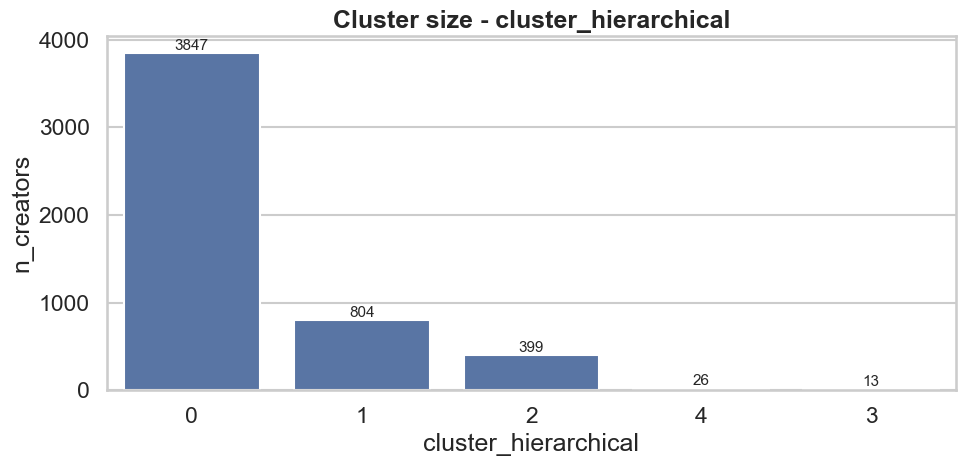

,cluster_hierarchical,n_creators,pct
0,0,3847,0.755944
1,1,804,0.157988
2,2,399,0.078404
3,4,26,0.005109
4,3,13,0.002555


,followerCnt,startingRate100k,recommendRate100k,followersGrowthRate,avgSixSecondsViewsRate,videoCompleteRate,engagementRate,medianViews,broadcastingScore,collaborationScore,commercialScore,total_views_recent
cluster_hierarchical,,,,,,,,,,,,
0,149076.0,0.000000e+00,1.248798e+11,0.0048,0.4139,0.0930,0.0463,36978.0,88.3,75.2,60.0,1204688.0
1,231518.0,1.960500e+11,1.446339e+11,-0.0000,0.2660,0.0585,0.0300,41250.0,87.5,84.4,90.4,1292234.0
2,216245.0,0.000000e+00,7.893419e+10,0.0079,0.4034,0.1187,0.0493,25734.0,88.8,75.6,60.0,1002977.0
3,97263.0,0.000000e+00,7.646330e+10,0.0137,0.4106,0.0984,0.0698,17322.0,91.2,75.2,60.0,679533.0
4,294100.5,1.500000e+10,7.075424e+10,-0.0015,0.3751,0.0261,0.0325,36341.0,85.7,77.4,60.0,1031365.0


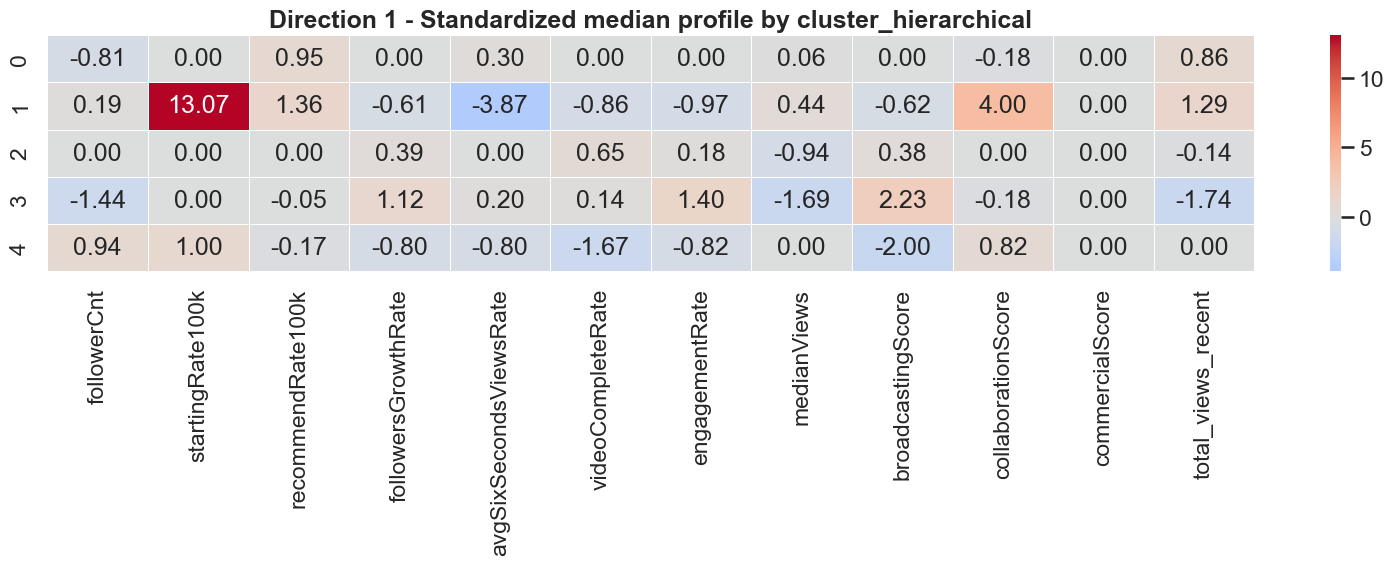

In [23]:

# =========================
# Direction 1
# Bản đồ tổng quan các cụm
# =========================

def direction_1_overview(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 1 - Tổng quan cụm")

    size_tbl = plot_cluster_sizes(df, cluster_col)
    display(size_tbl)
    export_table(size_tbl, f"{cluster_col}_direction_1_cluster_size")

    key_cols = [
        "followerCnt", "startingRate100k", "recommendRate100k",
        "followersGrowthRate", "avgSixSecondsViewsRate", "videoCompleteRate",
        "engagementRate", "medianViews", "broadcastingScore",
        "collaborationScore", "commercialScore", "total_views_recent"
    ]
    profile = summarize_by_cluster(df, cluster_col, key_cols, stat="median")
    profile_z = robust_standardize_table(profile)
    display(profile.round(4))
    plot_heatmap(profile_z, f"Direction 1 - Standardized median profile by {cluster_col}", figsize=(16, 6))
    export_table(profile.round(6), f"{cluster_col}_direction_1_profile_median")

direction_1_overview(df, CLUSTER_COL)


Direction 2 - Định vị giá và lệch giá


,startingRate100k,recommendRate100k,price_gap,price_ratio,commercialScore
cluster_hierarchical,,,,,
0,0.000000e+00,1.248798e+11,-8.534551e+10,0.000,60.0
1,1.960500e+11,1.446339e+11,-1.635326e+10,0.772,90.4
2,0.000000e+00,7.893419e+10,-5.185407e+10,0.000,60.0
3,0.000000e+00,7.646330e+10,-7.646330e+10,0.000,60.0
4,1.500000e+10,7.075424e+10,-2.357317e+10,0.625,60.0


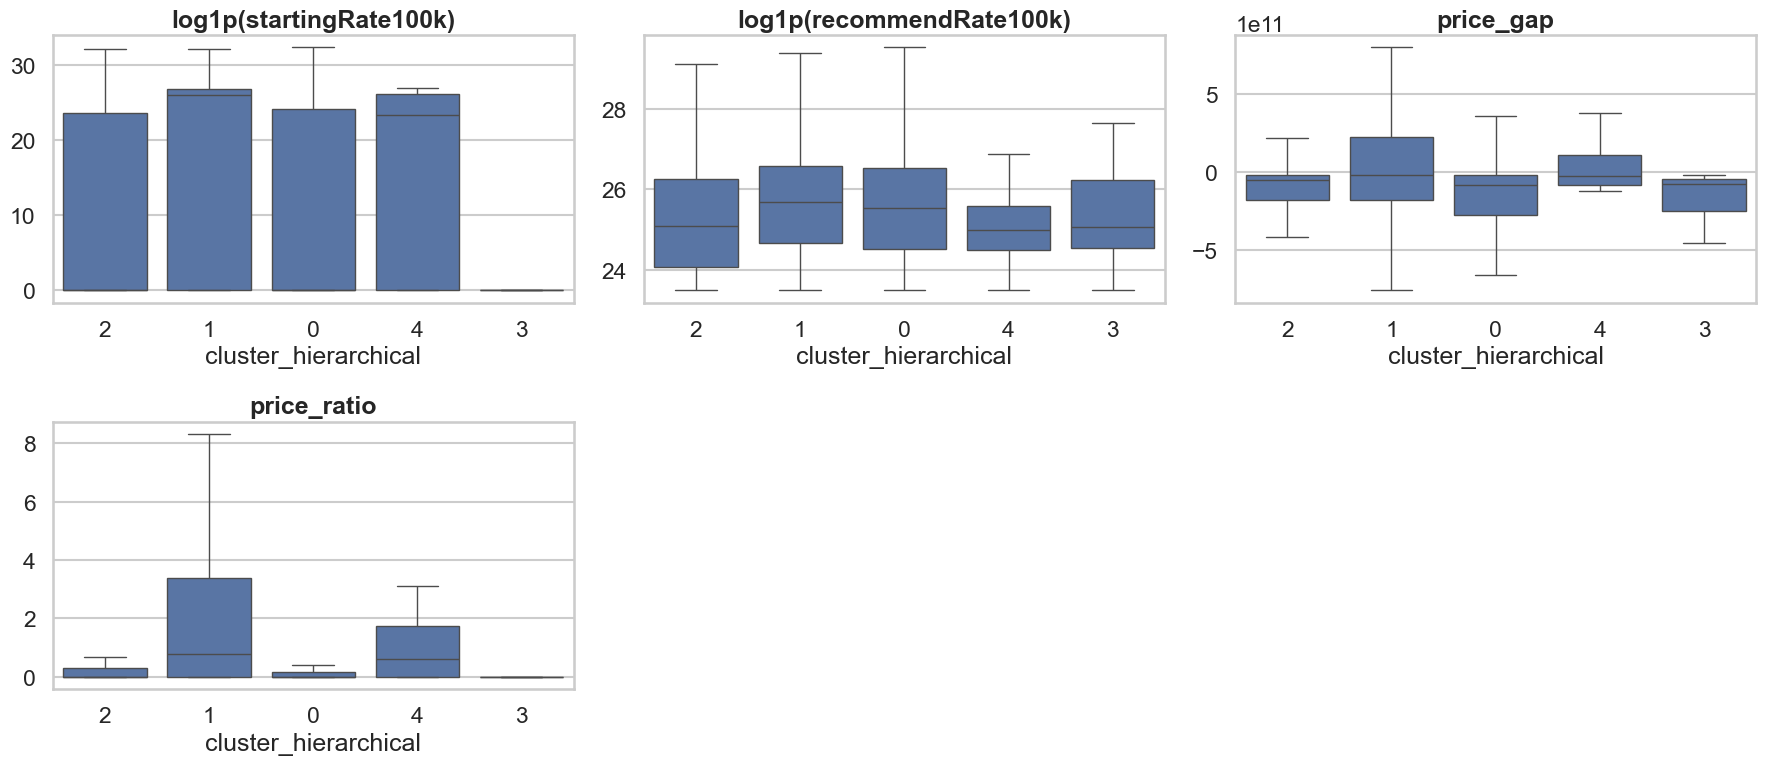

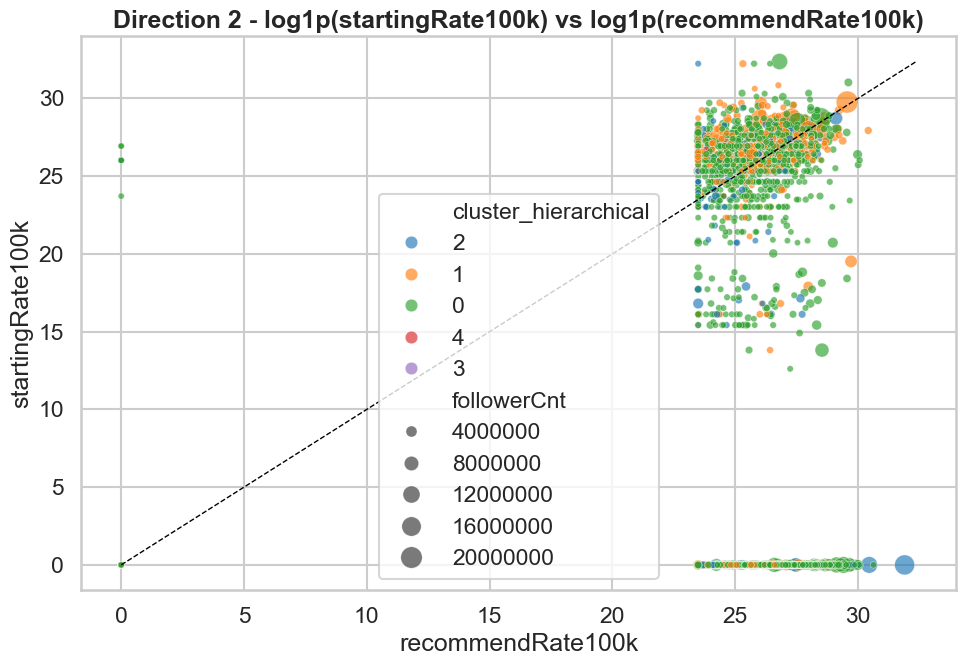

In [24]:

# =========================
# Direction 2
# Định vị giá và lệch giá
# =========================

def direction_2_price_positioning(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 2 - Định vị giá và lệch giá")

    summary_cols = ["startingRate100k", "recommendRate100k", "price_gap", "price_ratio", "commercialScore"]
    summary = summarize_by_cluster(df, cluster_col, summary_cols, stat="median")
    display(summary.round(4))
    export_table(summary.round(6), f"{cluster_col}_direction_2_price_summary")

    plot_box_grid(
        df, cluster_col,
        ["startingRate100k", "recommendRate100k", "price_gap", "price_ratio"],
        log_cols=["startingRate100k", "recommendRate100k"]
    )

    tmp = df[[cluster_col, "recommendRate100k", "startingRate100k", "followerCnt"]].copy()
    tmp["recommendRate100k"] = np.log1p(tmp["recommendRate100k"].clip(lower=0))
    tmp["startingRate100k"] = np.log1p(tmp["startingRate100k"].clip(lower=0))
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=tmp,
        x="recommendRate100k",
        y="startingRate100k",
        hue=cluster_col,
        size="followerCnt",
        sizes=(20, 250),
        alpha=0.65,
        palette="tab10",
    )
    min_val = min(tmp["recommendRate100k"].min(), tmp["startingRate100k"].min())
    max_val = max(tmp["recommendRate100k"].max(), tmp["startingRate100k"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", linewidth=1)
    plt.title("Direction 2 - log1p(startingRate100k) vs log1p(recommendRate100k)")
    plt.tight_layout()
    plt.show()

direction_2_price_positioning(df, CLUSTER_COL)


Direction 3 - Benchmark và relative competitiveness


,views_vs_benchmark,engagement_vs_benchmark,followersGrowthRateRank,avgSixSecondsViewsRateRank,medianViewsRank,videoCompleteRateRank,engagementRateRank
cluster_hierarchical,,,,,,,
0,7.0821,1.0775,0.7480,0.3229,0.1487,0.3806,0.4155
1,4.6731,0.7235,0.5765,0.7068,0.2013,0.1950,0.5817
2,3.2736,1.1800,0.7816,0.3497,0.2457,0.4608,0.3655
3,13.5849,1.5799,0.8517,0.2630,0.0922,0.4513,0.2472
4,5.4845,0.8125,0.3356,0.3810,0.1871,0.1138,0.5401


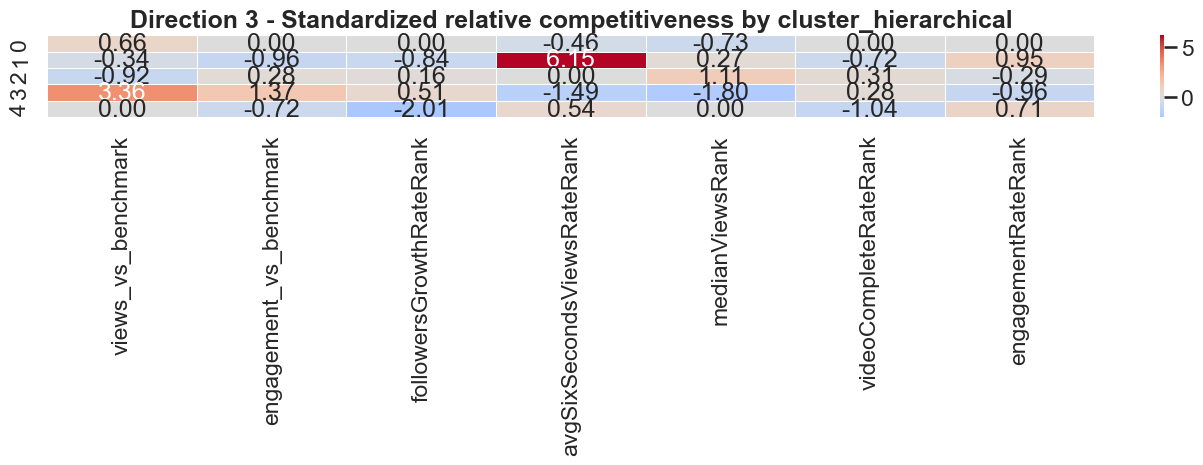

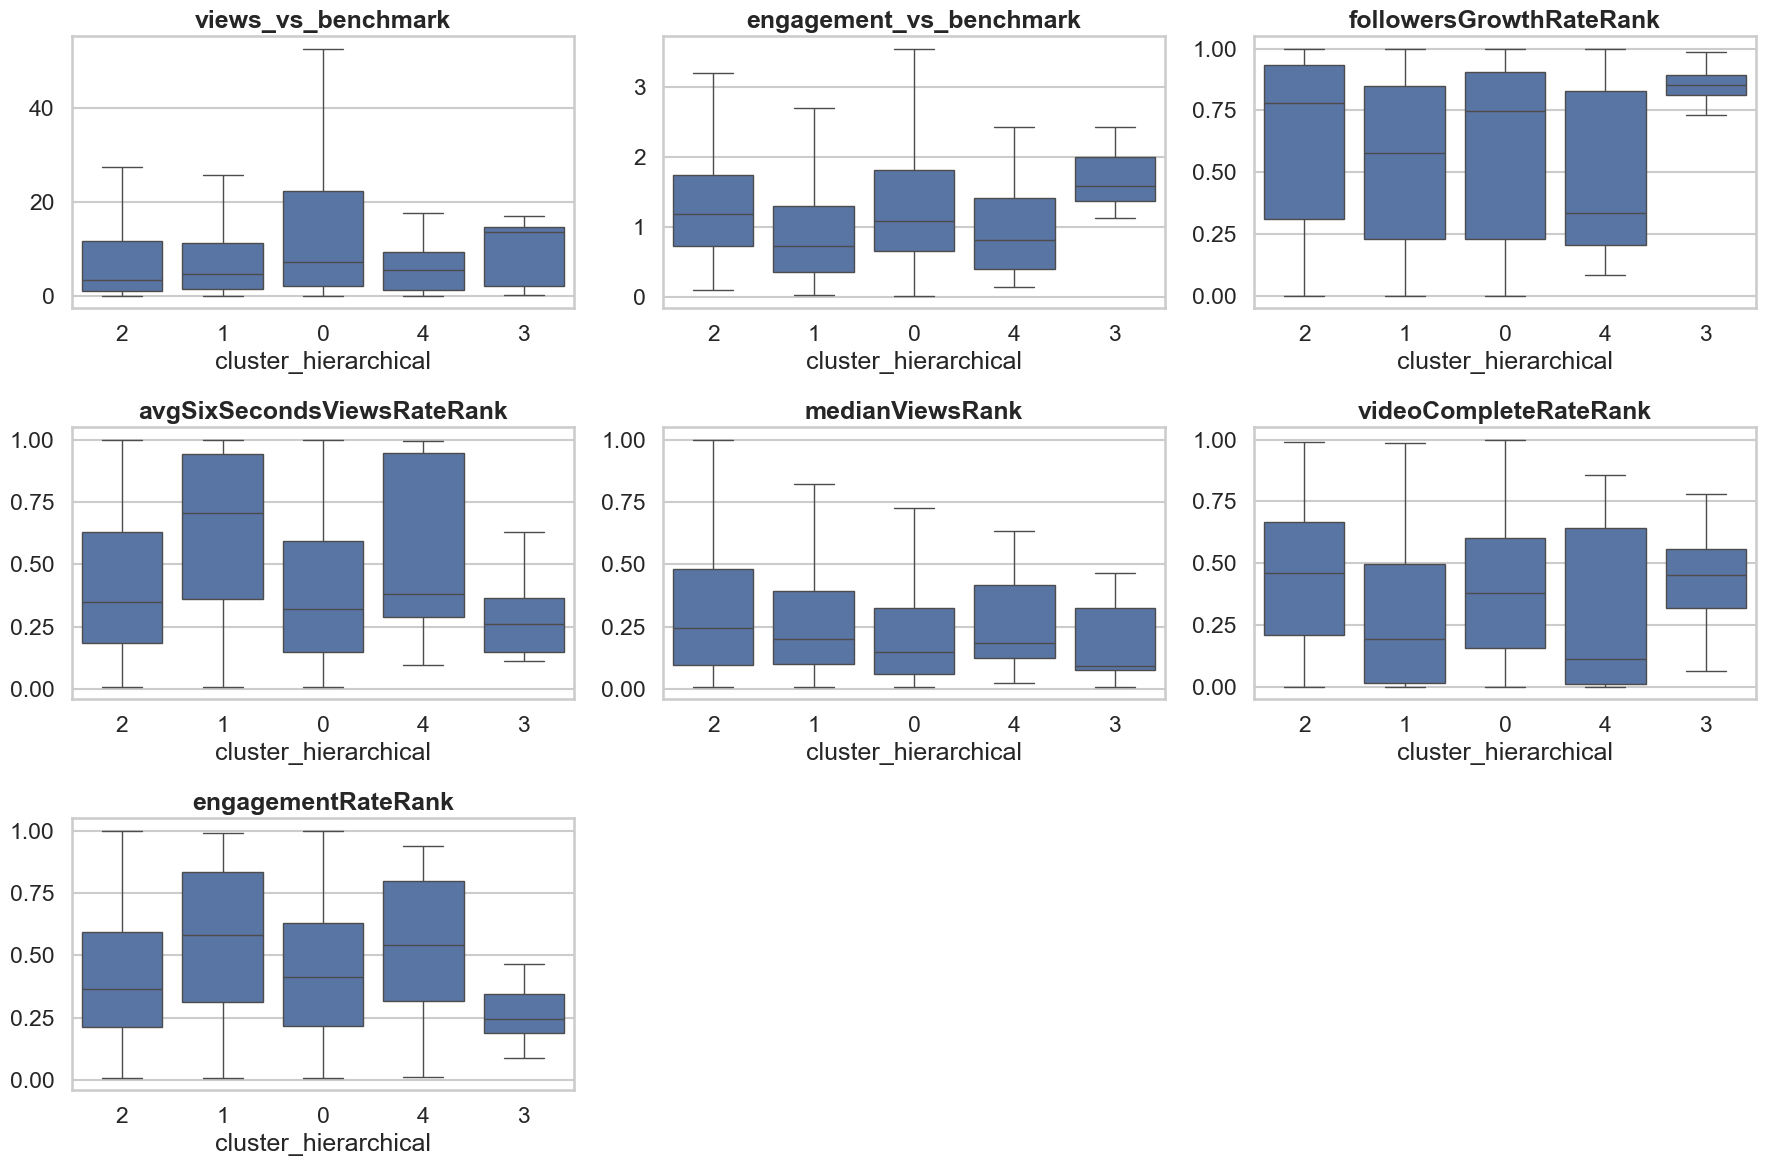

In [25]:

# =========================
# Direction 3
# Benchmark / relative competitiveness
# =========================

def direction_3_benchmark(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 3 - Benchmark và relative competitiveness")

    summary_cols = [
        "views_vs_benchmark", "engagement_vs_benchmark",
        "followersGrowthRateRank", "avgSixSecondsViewsRateRank",
        "medianViewsRank", "videoCompleteRateRank", "engagementRateRank"
    ]
    summary = summarize_by_cluster(df, cluster_col, summary_cols, stat="median")
    display(summary.round(4))
    export_table(summary.round(6), f"{cluster_col}_direction_3_benchmark_summary")

    heat_cols = ["views_vs_benchmark", "engagement_vs_benchmark"] + rank_cols
    heat = summarize_by_cluster(df, cluster_col, heat_cols, stat="median")
    heat_z = robust_standardize_table(heat)
    plot_heatmap(heat_z, f"Direction 3 - Standardized relative competitiveness by {cluster_col}", figsize=(14, 5))

    plot_box_grid(
        df, cluster_col,
        ["views_vs_benchmark", "engagement_vs_benchmark"] + rank_cols,
        ncols=3
    )

direction_3_benchmark(df, CLUSTER_COL)


Direction 4 - Hook vs retention


,avgSixSecondsViewsRate,videoCompleteRate,engagementRate,hook_hold_gap
cluster_hierarchical,,,,
0,0.4139,0.0930,0.0463,0.2927
1,0.2660,0.0585,0.0300,0.1775
2,0.4034,0.1187,0.0493,0.2655
3,0.4106,0.0984,0.0698,0.2940
4,0.3751,0.0261,0.0325,0.2491


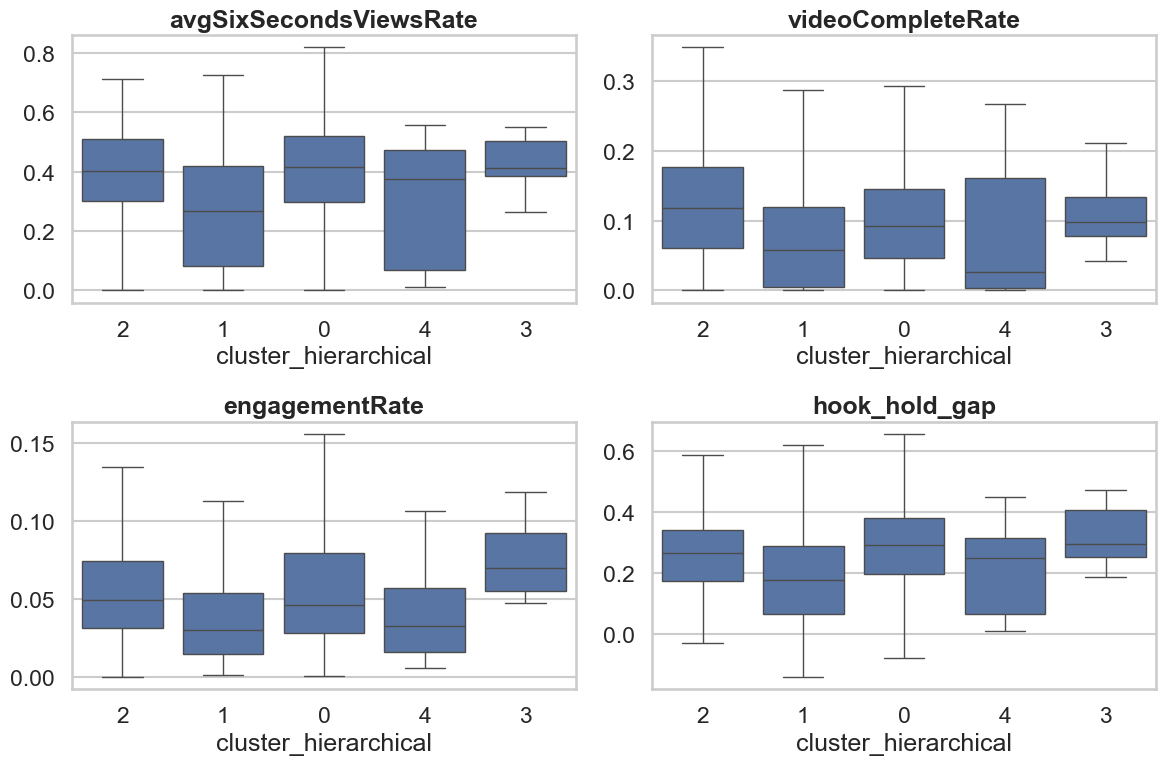

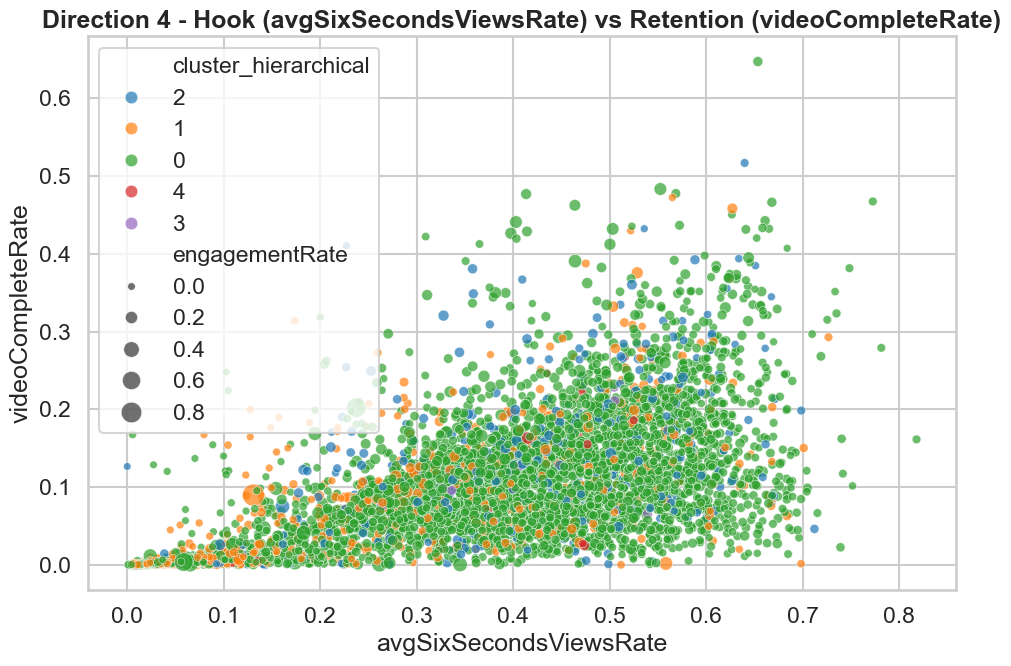

In [26]:

# =========================
# Direction 4
# Hook vs retention
# =========================

def direction_4_attention_retention(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 4 - Hook vs retention")

    summary_cols = ["avgSixSecondsViewsRate", "videoCompleteRate", "engagementRate", "hook_hold_gap"]
    summary = summarize_by_cluster(df, cluster_col, summary_cols, stat="median")
    display(summary.round(4))
    export_table(summary.round(6), f"{cluster_col}_direction_4_attention_retention")

    plot_box_grid(
        df, cluster_col,
        ["avgSixSecondsViewsRate", "videoCompleteRate", "engagementRate", "hook_hold_gap"],
        ncols=2
    )

    plot_cluster_scatter(
        df, cluster_col,
        x="avgSixSecondsViewsRate",
        y="videoCompleteRate",
        size="engagementRate",
        title="Direction 4 - Hook (avgSixSecondsViewsRate) vs Retention (videoCompleteRate)"
    )

direction_4_attention_retention(df, CLUSTER_COL)


Direction 5 - Organic -> collaboration -> commercial


,broadcastingScore,collaborationScore,commercialScore,organic_commercial_gap,collab_commercial_gap
cluster_hierarchical,,,,,
0,88.3,75.2,60.0,28.20,14.8
1,87.5,84.4,90.4,-3.10,-6.4
2,88.8,75.6,60.0,28.80,15.6
3,91.2,75.2,60.0,30.80,15.2
4,85.7,77.4,60.0,23.45,11.4


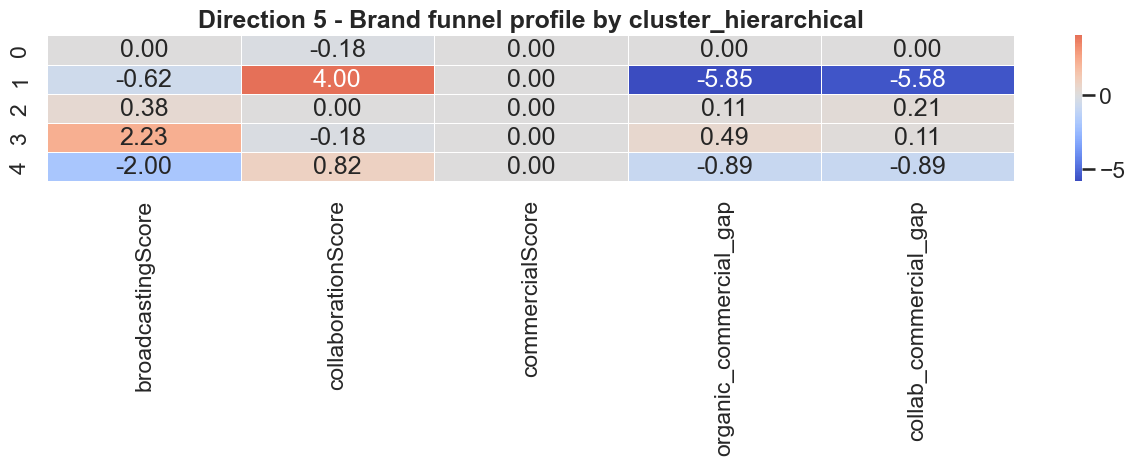

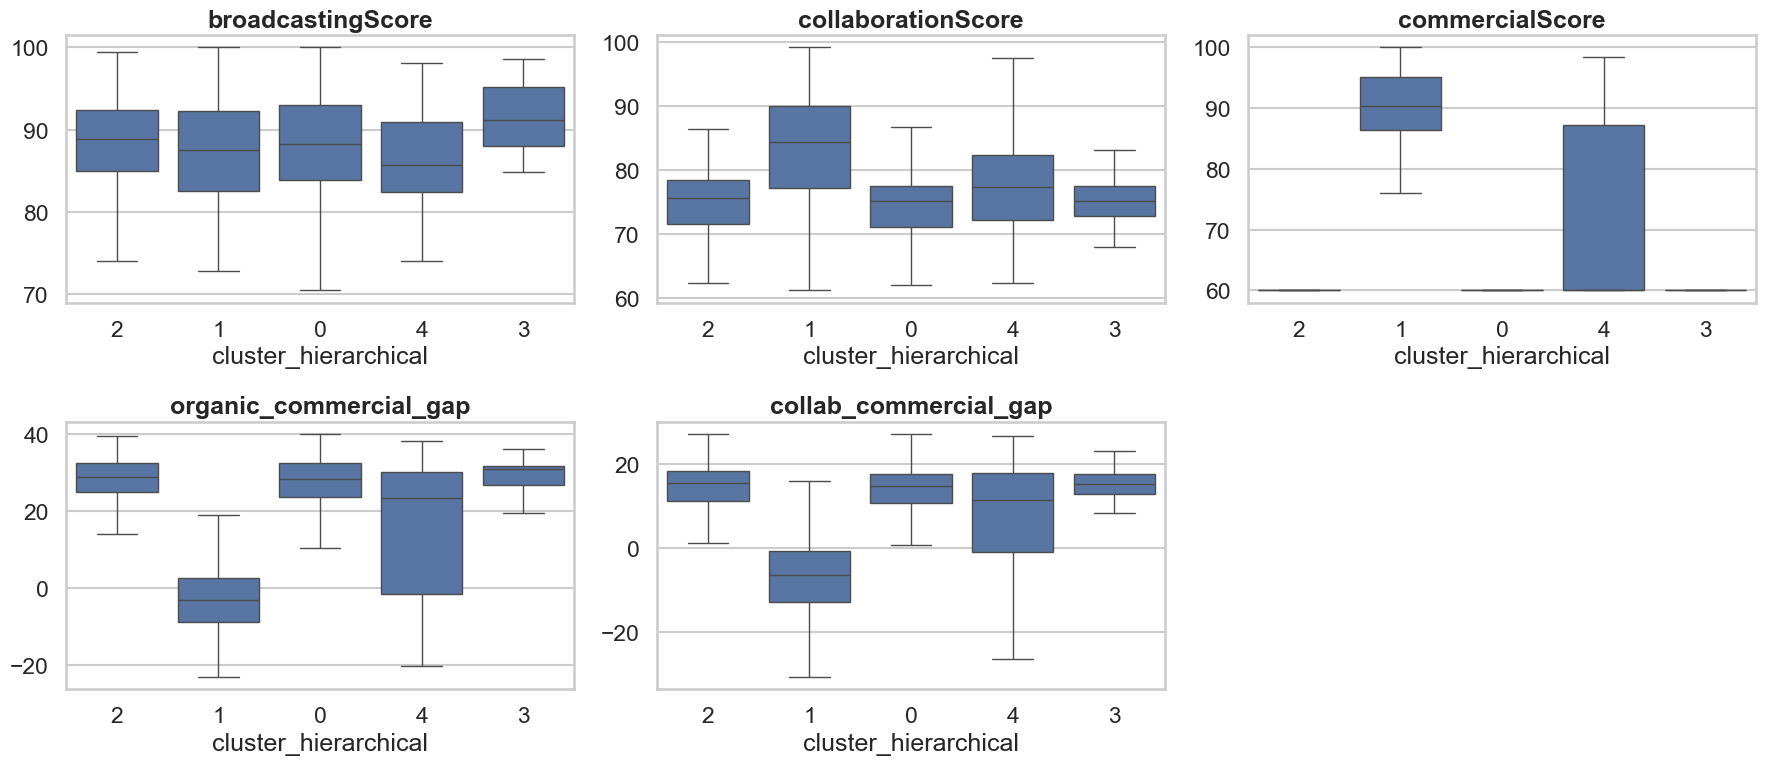

In [27]:

# =========================
# Direction 5
# Organic → collaboration → commercial
# =========================

def direction_5_brand_funnel(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 5 - Organic -> collaboration -> commercial")

    summary_cols = [
        "broadcastingScore", "collaborationScore", "commercialScore",
        "organic_commercial_gap", "collab_commercial_gap"
    ]
    summary = summarize_by_cluster(df, cluster_col, summary_cols, stat="median")
    display(summary.round(4))
    export_table(summary.round(6), f"{cluster_col}_direction_5_brand_funnel")

    heat = summarize_by_cluster(
        df, cluster_col,
        ["broadcastingScore", "collaborationScore", "commercialScore", "organic_commercial_gap", "collab_commercial_gap"],
        stat="median"
    )
    heat_z = robust_standardize_table(heat)
    plot_heatmap(heat_z, f"Direction 5 - Brand funnel profile by {cluster_col}", figsize=(13, 5))

    plot_box_grid(
        df, cluster_col,
        ["broadcastingScore", "collaborationScore", "commercialScore", "organic_commercial_gap", "collab_commercial_gap"],
        ncols=3
    )

direction_5_brand_funnel(df, CLUSTER_COL)


Direction 6 - Recent momentum và stability


,followersGrowthRate,total_views_recent,median_view_recent,max_view_recent,spike_ratio,cov_view_recent,burstiness_recent,recency_days_recent,recent_momentum_proxy
cluster_hierarchical,,,,,,,,,
0,0.0048,1204688.0,36325.0,379596.0,8.8026,1.2357,-0.0499,2.4925,22.9830
1,-0.0000,1292234.0,43521.5,351832.0,8.0163,1.1943,-0.0305,2.4961,23.2968
2,0.0079,1002977.0,25467.0,265570.0,9.6003,1.2561,-0.0182,2.4796,22.3598
3,0.0137,679533.0,19262.0,196828.0,10.2409,1.3195,-0.0369,2.4930,21.4396
4,-0.0015,1031365.0,33586.0,194211.0,7.0699,1.2158,0.0132,3.6475,22.7805


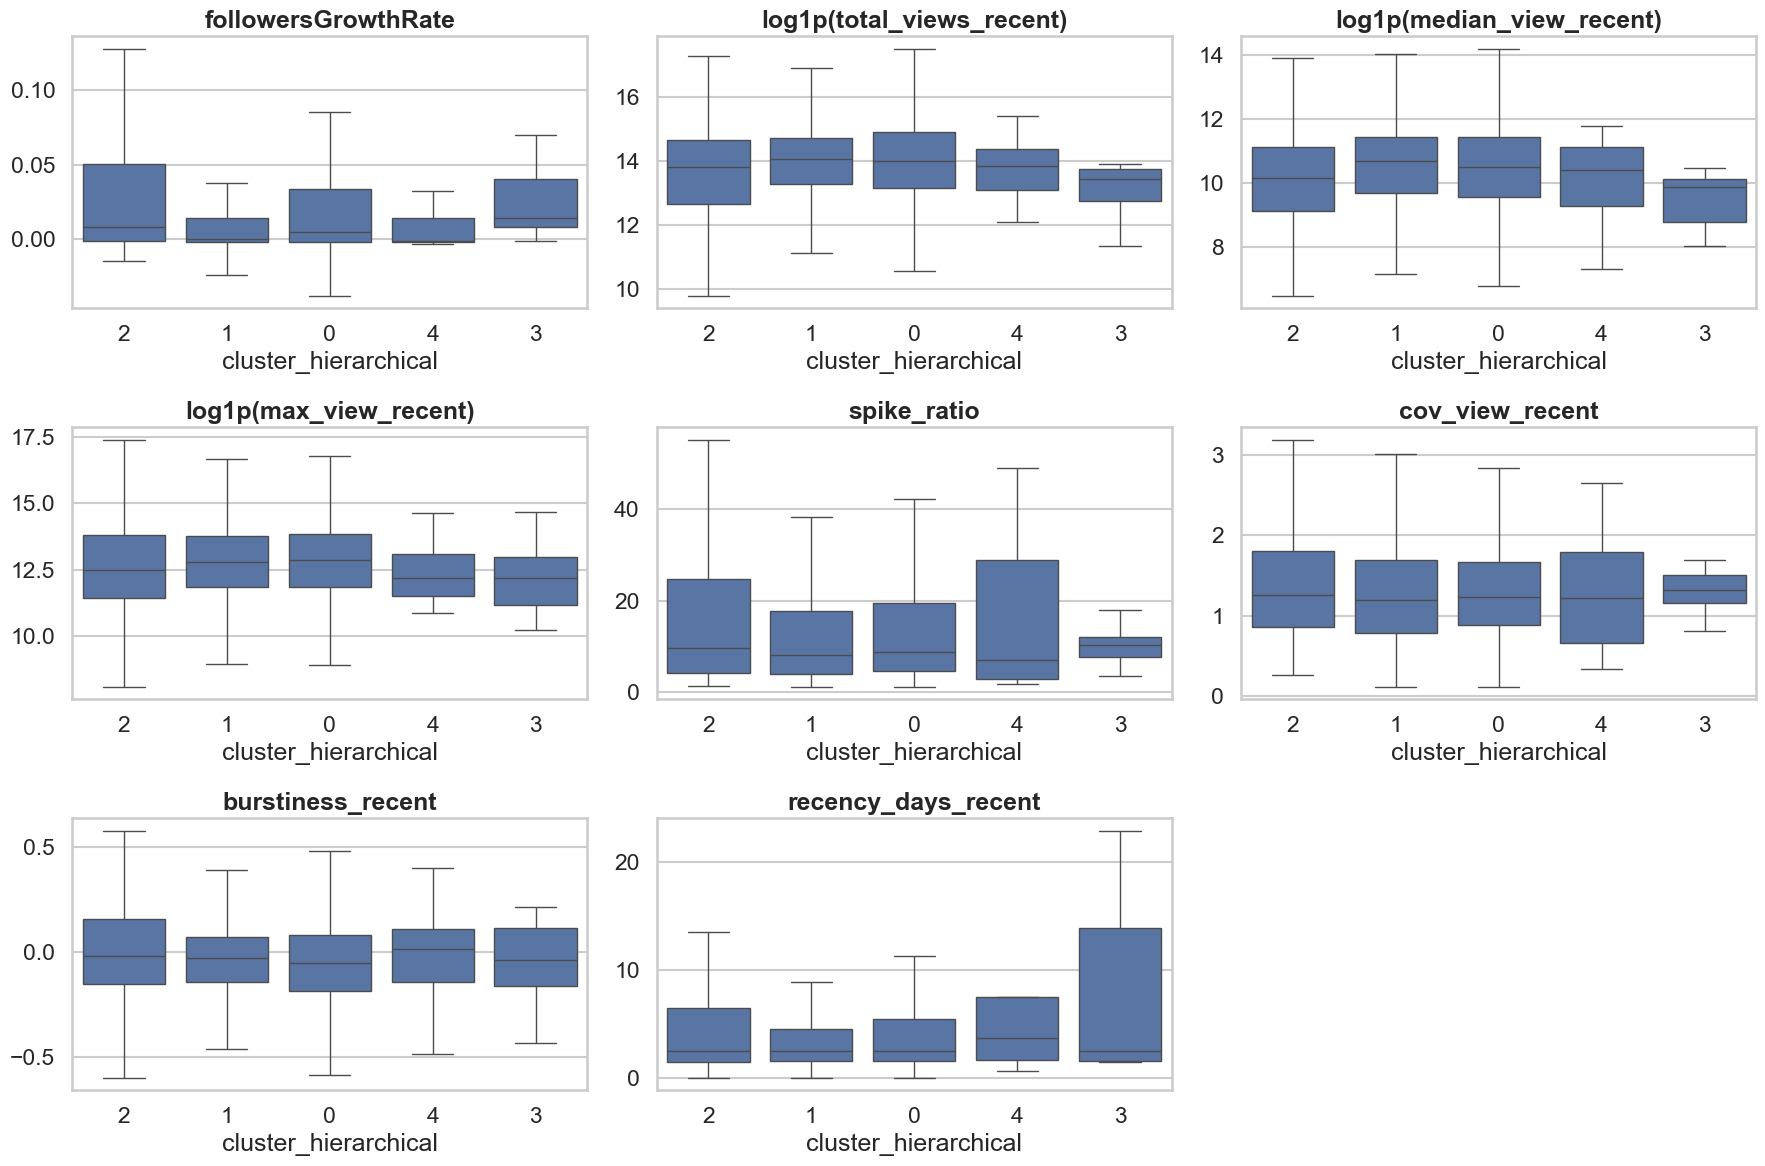

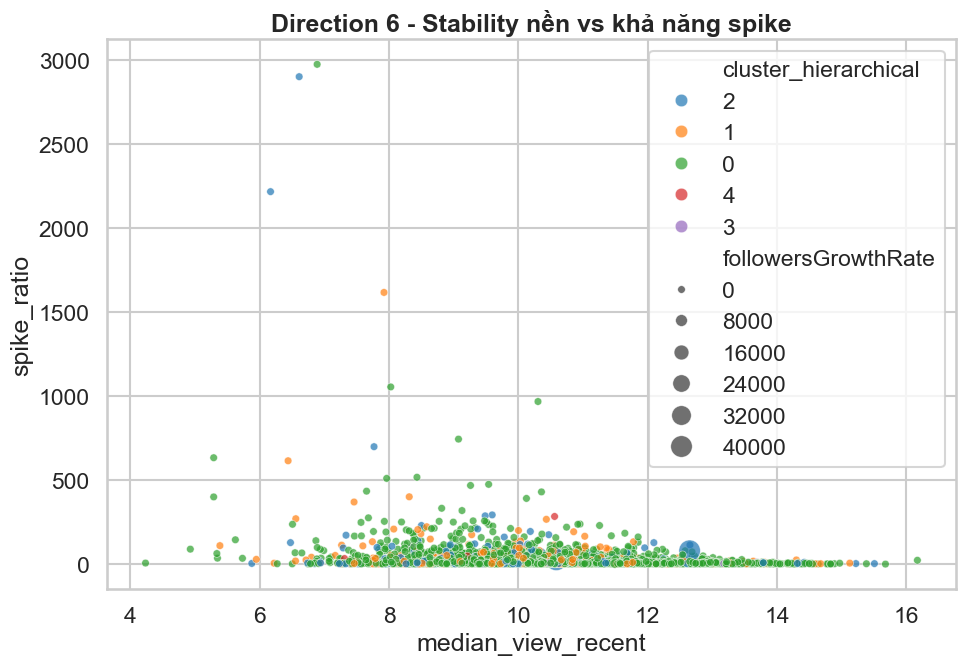

In [28]:

# =========================
# Direction 6
# Recent momentum và stability
# =========================

def direction_6_recent_momentum(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 6 - Recent momentum và stability")

    summary_cols = [
        "followersGrowthRate", "total_views_recent", "median_view_recent",
        "max_view_recent", "spike_ratio", "cov_view_recent",
        "burstiness_recent", "recency_days_recent", "recent_momentum_proxy"
    ]
    summary = summarize_by_cluster(df, cluster_col, summary_cols, stat="median")
    display(summary.round(4))
    export_table(summary.round(6), f"{cluster_col}_direction_6_recent_momentum")

    plot_box_grid(
        df, cluster_col,
        ["followersGrowthRate", "total_views_recent", "median_view_recent", "max_view_recent",
         "spike_ratio", "cov_view_recent", "burstiness_recent", "recency_days_recent"],
        ncols=3,
        log_cols=["total_views_recent", "median_view_recent", "max_view_recent"]
    )

    plot_cluster_scatter(
        df, cluster_col,
        x="median_view_recent",
        y="spike_ratio",
        size="followersGrowthRate",
        log_x=True,
        title="Direction 6 - Stability nền vs khả năng spike"
    )

direction_6_recent_momentum(df, CLUSTER_COL)


Direction 7 - Audience fit


,active_active,age_13-17,age_18-24,age_25-34,age_35-44,age_45-54,age_55+,age_Other,device_APPLE,device_SAMSUNG,device_OPPO,device_XIAOMI,device_VIVO,device_Other,gender_Female,gender_Male,country_VN,country_US,country_JP,country_TW,country_KR,country_MM,country_KH,country_TH,country_PH,country_ID
cluster_hierarchical,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.6458,0.0582,0.2996,0.3734,0.1402,0.0326,0.0232,0.0415,0.4146,0.1969,0.1765,0.0906,0.0486,0.0680,0.4169,0.5831,0.8495,0.0107,0.0052,0.0060,0.0030,0.0039,0.0035,0.0091,0.0068,0.0074
1,0.4914,0.0712,0.3040,0.3391,0.1212,0.0207,0.0161,0.0924,0.3741,0.2106,0.1869,0.0870,0.0541,0.0816,0.4229,0.5771,0.8299,0.0108,0.0047,0.0036,0.0022,0.0093,0.0033,0.0111,0.0081,0.0109
2,0.6385,0.0718,0.2826,0.3591,0.1475,0.0416,0.0333,0.0257,0.2600,0.1745,0.1834,0.1365,0.0731,0.1593,0.3587,0.6413,0.4071,0.0023,0.0007,0.0087,0.0019,0.1060,0.0309,0.0617,0.0385,0.0444
3,0.6664,0.0770,0.2901,0.3691,0.1472,0.0237,0.0429,0.0137,0.3535,0.0918,0.2758,0.0332,0.1023,0.1111,0.3210,0.6790,0.2405,0.0015,0.0011,0.0058,0.0035,0.0073,0.6431,0.0461,0.0010,0.0010
4,0.4598,0.0721,0.3084,0.3519,0.1350,0.0295,0.0385,0.0194,0.1364,0.1374,0.1974,0.2310,0.1036,0.1772,0.3061,0.6939,0.2341,0.0015,0.0000,0.0000,0.0000,0.3603,0.0164,0.0875,0.0351,0.0330


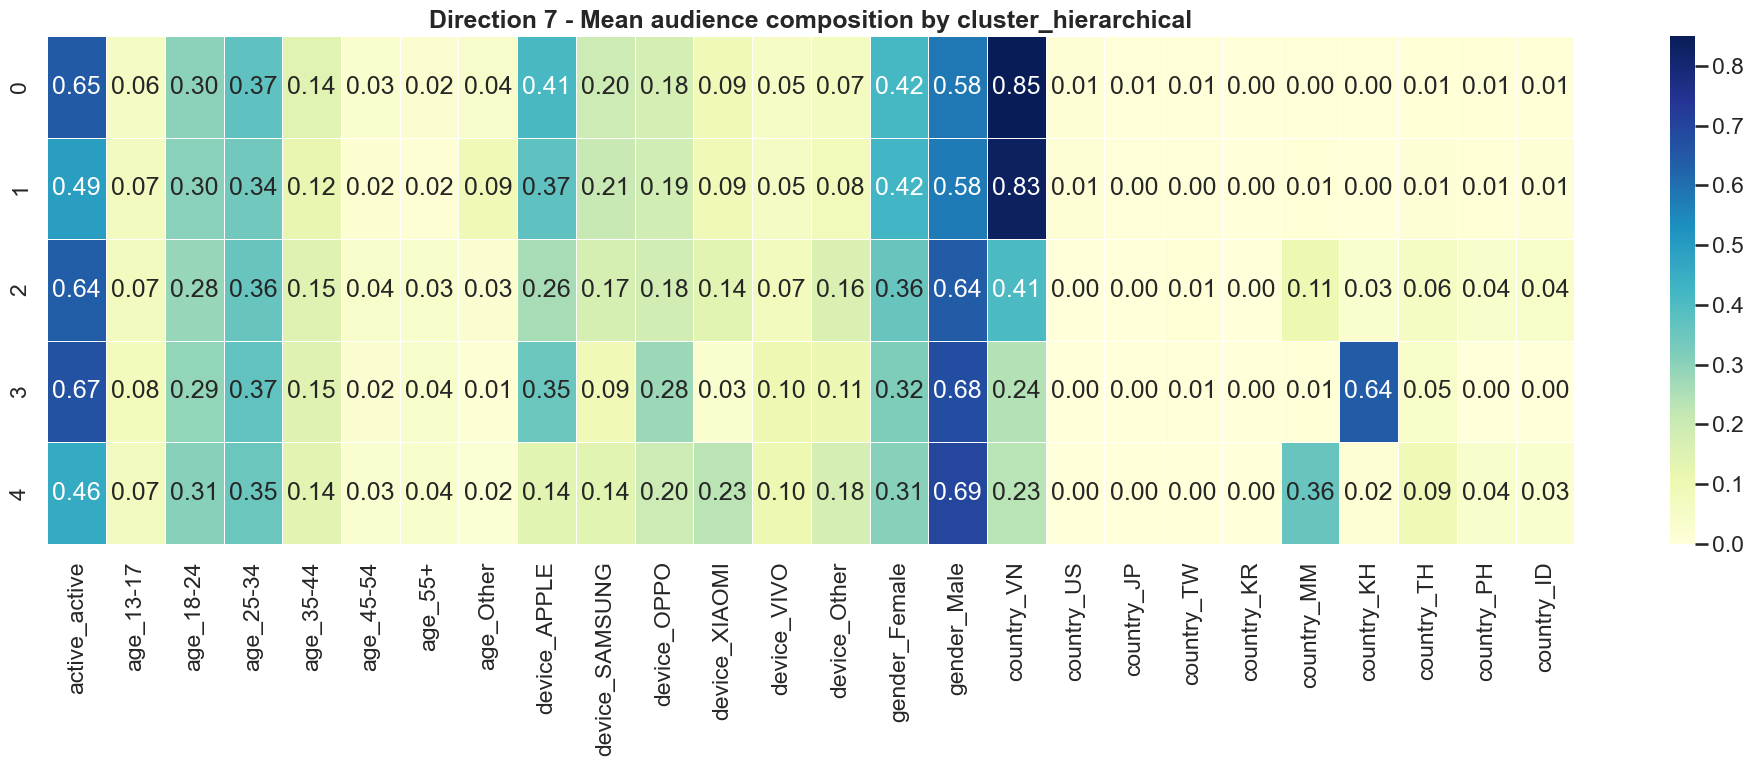


Dominant age per cluster


,cluster_hierarchical,dominant_age,n,pct_within_cluster
1,0,age_25-34,2202,0.572394
0,0,age_18-24,1266,0.329088
5,0,age_Other,193,0.050169
7,1,age_25-34,388,0.482587
6,1,age_18-24,304,0.378109
10,1,age_Other,98,0.121891
12,2,age_25-34,267,0.669173
11,2,age_18-24,118,0.295739
15,2,age_Other,7,0.017544
17,3,age_25-34,8,0.615385



Dominant device per cluster


,cluster_hierarchical,dominant_device,n,pct_within_cluster
0,0,device_APPLE,3063,0.796205
3,0,device_SAMSUNG,345,0.089680
1,0,device_OPPO,339,0.088121
5,1,device_APPLE,572,0.711443
8,1,device_SAMSUNG,112,0.139303
6,1,device_OPPO,92,0.114428
10,2,device_APPLE,220,0.551378
12,2,device_Other,86,0.215539
11,2,device_OPPO,65,0.162907
14,3,device_APPLE,8,0.615385



Dominant gender per cluster


,cluster_hierarchical,dominant_gender,n,pct_within_cluster
1,0,gender_Male,2482,0.645178
0,0,gender_Female,1365,0.354822
3,1,gender_Male,525,0.652985
2,1,gender_Female,279,0.347015
5,2,gender_Male,288,0.721805
4,2,gender_Female,111,0.278195
7,3,gender_Male,11,0.846154
6,3,gender_Female,2,0.153846
9,4,gender_Male,21,0.807692
8,4,gender_Female,5,0.192308



Dominant country per cluster


,cluster_hierarchical,dominant_country,n,pct_within_cluster
8,0,country_VN,3732,0.970107
7,0,country_US,42,0.010918
4,0,country_PH,30,0.007798
14,1,country_VN,792,0.985075
10,1,country_MM,5,0.006219
13,1,country_US,3,0.003731
21,2,country_VN,325,0.814536
18,2,country_MM,37,0.092732
19,2,country_PH,18,0.045113
22,3,country_KH,10,0.769231


In [29]:

# =========================
# Direction 7
# Audience fit
# =========================

age_cols = ["age_13-17", "age_18-24", "age_25-34", "age_35-44", "age_45-54", "age_55+", "age_Other"]
device_cols = ["device_APPLE", "device_SAMSUNG", "device_OPPO", "device_XIAOMI", "device_VIVO", "device_Other"]
gender_cols = ["gender_Female", "gender_Male"]
country_cols = ["country_VN", "country_US", "country_JP", "country_TW", "country_KR", "country_MM", "country_KH", "country_TH", "country_PH", "country_ID"]

def direction_7_audience_fit(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 7 - Audience fit")

    audience_summary = summarize_by_cluster(df, cluster_col, ["active_active"] + age_cols + device_cols + gender_cols + country_cols, stat="mean")
    display(audience_summary.round(4).head())
    export_table(audience_summary.round(6), f"{cluster_col}_direction_7_audience_fit")

    plot_heatmap(
        audience_summary,
        f"Direction 7 - Mean audience composition by {cluster_col}",
        center=None,
        cmap="YlGnBu",
        fmt=".2f",
        figsize=(20, 8)
    )

    for prefix, cols in [("age", age_cols), ("device", device_cols), ("gender", gender_cols), ("country", country_cols)]:
        print(f"\nDominant {prefix} per cluster")
        dom = dominant_label_table(df, cluster_col, cols, prefix)
        display(dom.groupby(cluster_col).head(3))

direction_7_audience_fit(df, CLUSTER_COL)


Direction 8 - Content vertical archetypes


,Beauty,Education,Entertainment,Food,Sports
cluster_hierarchical,,,,,
0,0.2311,0.0432,0.5620,0.2233,0.0205
1,0.5933,0.0236,0.2861,0.2326,0.0286
2,0.1779,0.0150,0.7143,0.1479,0.0376
3,0.0000,0.0769,0.6923,0.3846,0.0000
4,0.4231,0.0000,0.4615,0.1538,0.0385


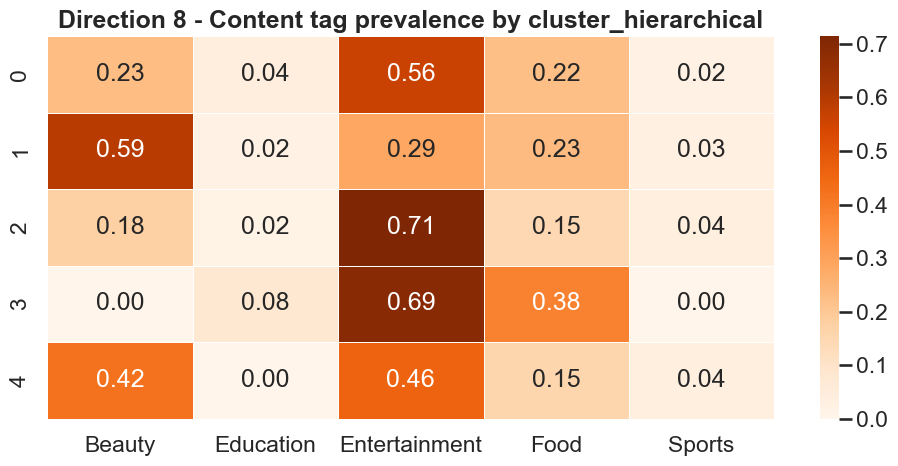

,content_tag,n_creators,engagementRate,videoCompleteRate,commercialScore,medianViews
2,Entertainment,2698,0.0578,0.1192,60.0,32917.5
0,Beauty,1448,0.0321,0.0504,60.0,39312.0
3,Food,1114,0.0313,0.0555,60.0,51487.0
1,Education,192,0.0525,0.0713,60.0,20681.0
4,Sports,118,0.0296,0.0873,60.0,32204.0


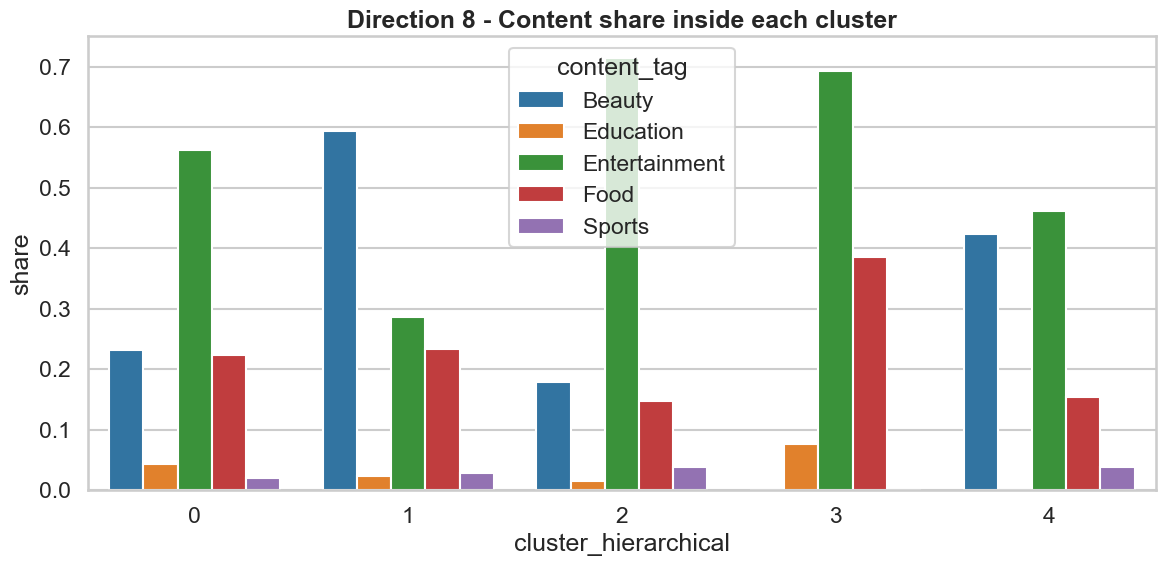

In [30]:

# =========================
# Direction 8
# Content vertical archetypes
# =========================

def direction_8_content_vertical(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 8 - Content vertical archetypes")

    content_summary = summarize_by_cluster(df, cluster_col, content_cols, stat="mean")
    display(content_summary.round(4))
    export_table(content_summary.round(6), f"{cluster_col}_direction_8_content_mix")

    plot_heatmap(
        content_summary,
        f"Direction 8 - Content tag prevalence by {cluster_col}",
        center=None,
        cmap="Oranges",
        fmt=".2f",
        figsize=(10, 5)
    )

    # Hiệu suất trung vị bên trong từng content tag
    records = []
    metrics = ["engagementRate", "videoCompleteRate", "commercialScore", "medianViews"]
    for tag in content_cols:
        sub = df[df[tag] == 1]
        if len(sub) == 0:
            continue
        row = {"content_tag": tag, "n_creators": len(sub)}
        for m in metrics:
            row[m] = sub[m].median()
        records.append(row)

    content_perf = pd.DataFrame(records).sort_values("n_creators", ascending=False)
    display(content_perf.round(4))

    melted = content_summary.reset_index().melt(id_vars=cluster_col, value_vars=content_cols, var_name="content_tag", value_name="share")
    plt.figure(figsize=(12, 6))
    sns.barplot(data=melted, x=cluster_col, y="share", hue="content_tag", palette="tab10")
    plt.title("Direction 8 - Content share inside each cluster")
    plt.tight_layout()
    plt.show()

direction_8_content_vertical(df, CLUSTER_COL)


Direction 9 - Mâu thuẫn nội tại của cụm


,price_gap,price_ratio,views_vs_benchmark,engagement_vs_benchmark,hook_hold_gap,organic_commercial_gap,collab_commercial_gap,spike_ratio,active_utilization
cluster_hierarchical,,,,,,,,,
0,-8.534551e+10,0.000,7.0821,1.0775,0.2927,28.20,14.8,8.8026,0.0797
1,-1.635326e+10,0.772,4.6731,0.7235,0.1775,-3.10,-6.4,8.0163,0.0757
2,-5.185407e+10,0.000,3.2736,1.1800,0.2655,28.80,15.6,9.6003,0.0829
3,-7.646330e+10,0.000,13.5849,1.5799,0.2940,30.80,15.2,10.2409,0.0990
4,-2.357317e+10,0.625,5.4845,0.8125,0.2491,23.45,11.4,7.0699,0.0857


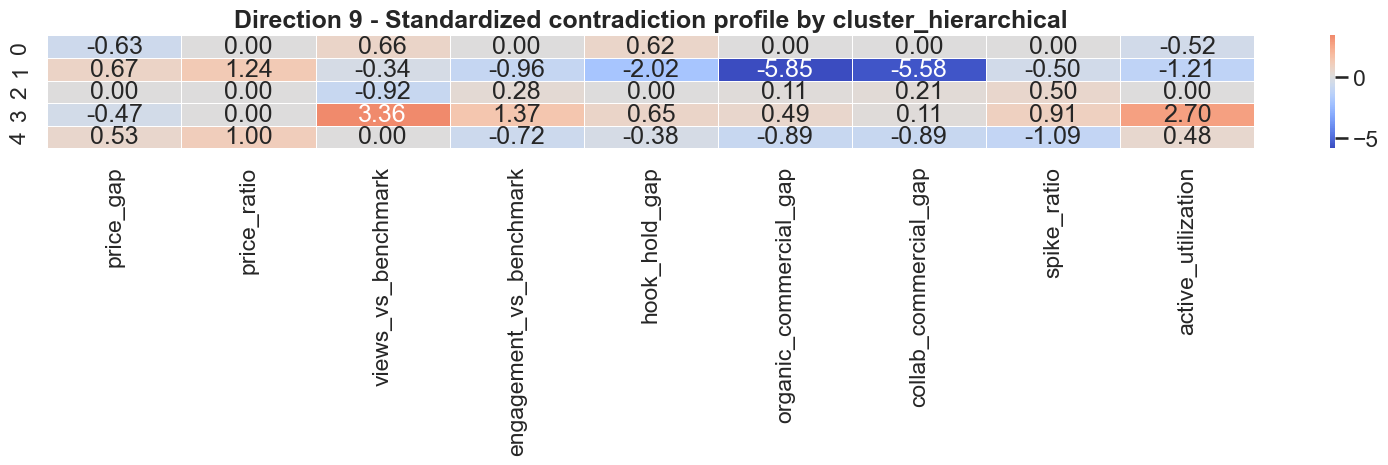

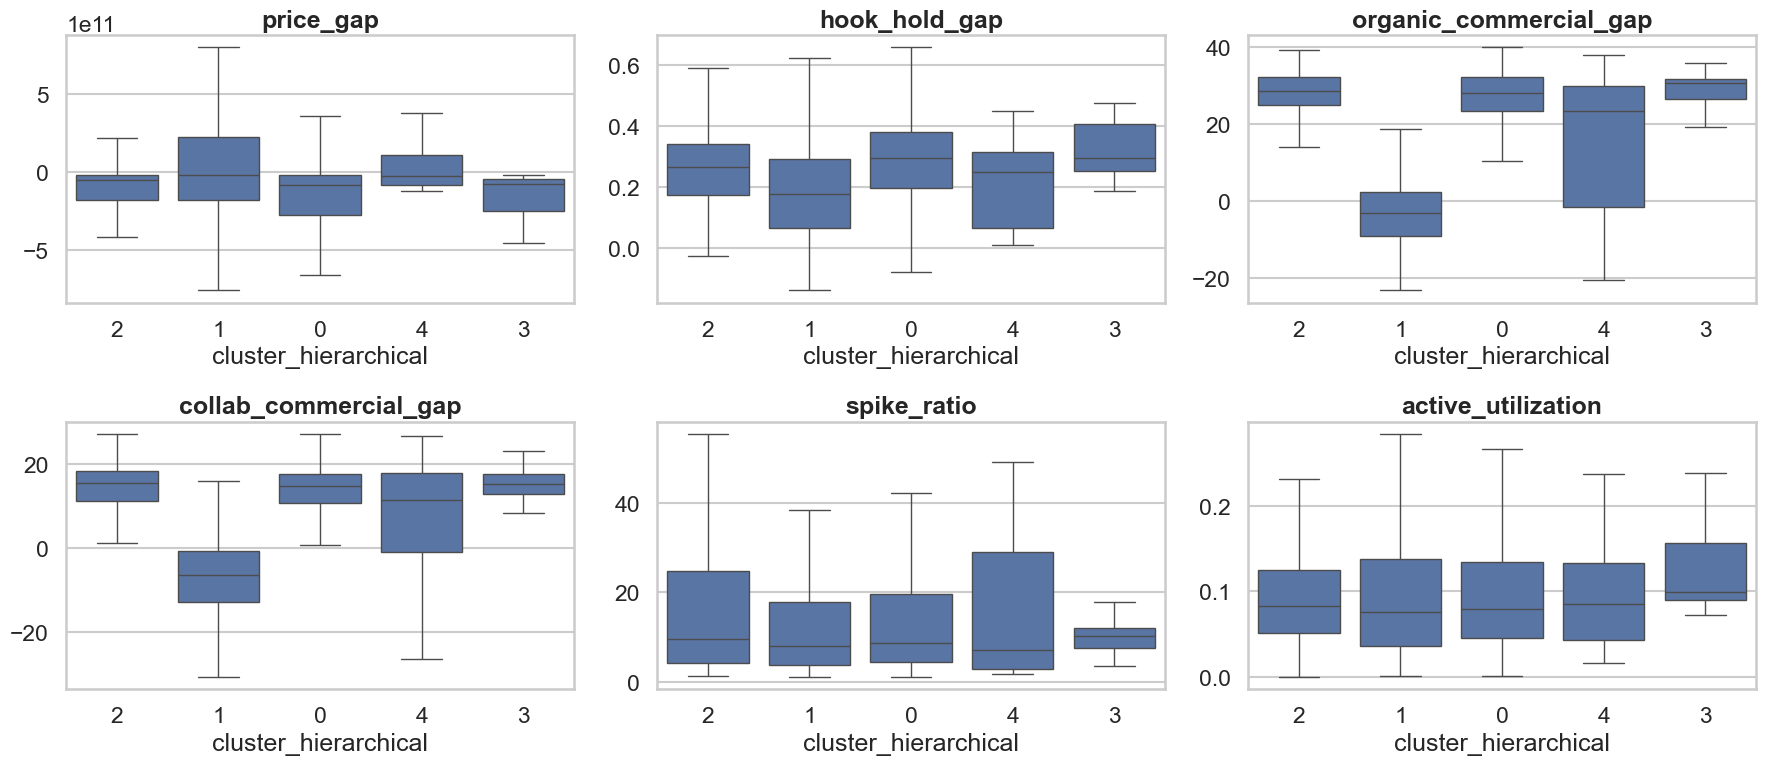

In [31]:

# =========================
# Direction 9
# Mâu thuẫn nội tại của cụm
# =========================

def direction_9_internal_tensions(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 9 - Mâu thuẫn nội tại của cụm")

    tension_cols = [
        "price_gap",
        "price_ratio",
        "views_vs_benchmark",
        "engagement_vs_benchmark",
        "hook_hold_gap",
        "organic_commercial_gap",
        "collab_commercial_gap",
        "spike_ratio",
        "active_utilization",
    ]

    tension_summary = summarize_by_cluster(df, cluster_col, tension_cols, stat="median")
    display(tension_summary.round(4))
    export_table(tension_summary.round(6), f"{cluster_col}_direction_9_internal_tensions")

    tension_z = robust_standardize_table(tension_summary)
    plot_heatmap(
        tension_z,
        f"Direction 9 - Standardized contradiction profile by {cluster_col}",
        figsize=(16, 5)
    )

    plot_box_grid(
        df, cluster_col,
        ["price_gap", "hook_hold_gap", "organic_commercial_gap", "collab_commercial_gap", "spike_ratio", "active_utilization"],
        ncols=3
    )

direction_9_internal_tensions(df, CLUSTER_COL)


Direction 10 - Opportunity map


,cluster_hierarchical,price_gap,commercialScore,followersGrowthRate,recent_stability_proxy,recent_momentum_proxy,underpricing_score,commercial_strength_score,growth_score,stability_score,momentum_score,opportunity_label
0,0,-8.534551e+10,60.0,0.0048,0.4473,22.9830,1.2592,-0.5,-0.0306,0.1856,0.6396,Stable / fair-value
1,1,-1.635326e+10,90.4,-0.0000,0.4557,23.2968,-1.2497,2.0,-0.9047,1.1879,1.1279,Stable / fair-value
2,2,-5.185407e+10,60.0,0.0079,0.4432,22.3598,0.0413,-0.5,0.5341,-0.2971,-0.3301,Experimental bet
3,3,-7.646330e+10,60.0,0.0137,0.4311,21.4396,0.9362,-0.5,1.5817,-1.7396,-1.7620,Experimental bet
4,4,-2.357317e+10,60.0,-0.0015,0.4513,22.7805,-0.9871,-0.5,-1.1805,0.6633,0.3246,Overpriced risk


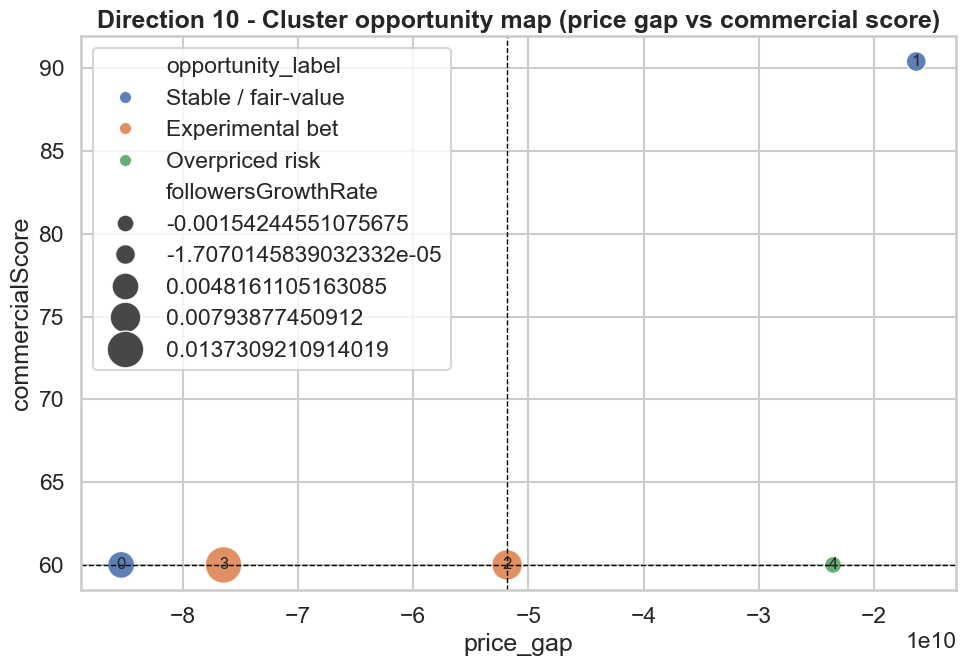

In [32]:

# =========================
# Direction 10
# Opportunity map
# =========================

def direction_10_opportunity_map(df: pd.DataFrame, cluster_col: str):
    print_section("Direction 10 - Opportunity map")

    cluster_medians = summarize_by_cluster(
        df, cluster_col,
        ["price_gap", "commercialScore", "followersGrowthRate", "recent_stability_proxy", "recent_momentum_proxy"],
        stat="median"
    ).reset_index()

    # Chuẩn hóa để dễ tạo score
    score_cols = ["price_gap", "commercialScore", "followersGrowthRate", "recent_stability_proxy", "recent_momentum_proxy"]
    z = cluster_medians[score_cols].copy()
    z = (z - z.mean()) / z.std(ddof=0).replace(0, np.nan)
    z = z.fillna(0)

    cluster_medians["underpricing_score"] = -z["price_gap"]
    cluster_medians["commercial_strength_score"] = z["commercialScore"]
    cluster_medians["growth_score"] = z["followersGrowthRate"]
    cluster_medians["stability_score"] = z["recent_stability_proxy"]
    cluster_medians["momentum_score"] = z["recent_momentum_proxy"]

    def classify(row):
        if row["underpricing_score"] > 0 and row["commercial_strength_score"] > 0:
            return "Hidden gem"
        if row["underpricing_score"] < 0 and row["commercial_strength_score"] < 0:
            return "Overpriced risk"
        if row["growth_score"] > 0 and row["stability_score"] < 0:
            return "Experimental bet"
        return "Stable / fair-value"

    cluster_medians["opportunity_label"] = cluster_medians.apply(classify, axis=1)

    display(cluster_medians.round(4))
    export_table(cluster_medians.round(6), f"{cluster_col}_direction_10_opportunity_map")

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=cluster_medians,
        x="price_gap",
        y="commercialScore",
        hue="opportunity_label",
        size="followersGrowthRate",
        sizes=(150, 700),
        alpha=0.9,
    )
    for _, row in cluster_medians.iterrows():
        plt.text(row["price_gap"], row["commercialScore"], str(row[cluster_col]), fontsize=12, ha="center", va="center")
    plt.axvline(cluster_medians["price_gap"].median(), linestyle="--", color="black", linewidth=1)
    plt.axhline(cluster_medians["commercialScore"].median(), linestyle="--", color="black", linewidth=1)
    plt.title("Direction 10 - Cluster opportunity map (price gap vs commercial score)")
    plt.tight_layout()
    plt.show()

direction_10_opportunity_map(df, CLUSTER_COL)

## Gợi ý workflow thực tế
- Bắt đầu bằng `cluster_spectral` hoặc model bạn chọn cuối cùng.
- Sau khi chạy xong 10 hướng, chỉ giữ lại những biểu đồ phục vụ **1 câu chuyện chính**.
- Đừng diễn giải mọi khác biệt là insight; chỉ giữ:
  1. khác biệt lớn  
  2. khác biệt ổn định qua nhiều biểu đồ  
  3. khác biệt có ý nghĩa hành động  

## Gợi ý diễn giải cuối cùng
Bạn có thể chốt mỗi cụm theo khung:
- **Cluster label:** ví dụ `Underpriced high-potential creators`
- **Mạnh ở đâu**
- **Yếu ở đâu**
- **Mâu thuẫn nội tại**
- **Hàm ý cho brand**
- **Hàm ý cho platform**
- **Hàm ý cho creator**